# Sentiment Analysis
Lucas Andersen (pbp8nq@virginia.edu​) 

DS 5001

May 8, 2026

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set(style='ticks')

F1_path = 'data/F1'
F3_path = 'data/F3'
F4_path = 'data/F4'
F5_path = 'data/F5'
LEX_path = f"{F5_path}/sentiment_analysis"
os.makedirs(F5_path+"/sentiment_analysis/figures", exist_ok=True)

## Configuration

In [42]:
OHCO = ['work_id','part_num','chap_num','para_num','sent_num','token_num']
WORKS = OHCO[:1]
PARAS = OHCO[:4]
SENTS = OHCO[:5]

emo_cols = "anger anticipation disgust fear joy sadness surprise trust polarity".split()

## Load NRC sentiment lexicon

In [43]:
salex = pd.read_csv(f"{LEX_path}/salex_nrc.csv").set_index('term_str')
salex.columns = [c.replace('nrc_','') for c in salex.columns]
salex['polarity'] = salex.positive - salex.negative

print(f"NRC Lexicon: {len(salex):,} terms")
salex.head()

NRC Lexicon: 3,688 terms


,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,polarity
term_str,,,,,,,,,,,
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abduction,0,0,0,1,0,1,0,1,1,0,-1
aberration,0,0,1,0,0,1,0,0,0,0,-1


## Load TOKEN

In [44]:
LIB = pd.read_csv(f"{F1_path}/LIB.csv", index_col = OHCO[0])
TOKEN = pd.read_csv(f"{F4_path}/TOKEN.csv", index_col=OHCO, keep_default_na=False, na_values = [])

print(f"LIB: {len(LIB)} works")
print(f"TOKEN: {len(TOKEN):,} tokens")

LIB: 49 works
TOKEN: 283,960 tokens


## Join lexicon onto TOKEN

In [45]:
TOKEN = TOKEN.join(salex, on='term_str', how='left')

sentiment_cols = list(salex.columns)
for col in sentiment_cols:
    TOKEN[col] = TOKEN[col].fillna(0)

matched = (TOKEN[emo_cols[:-1]].sum(axis=1) > 0).sum()
print(f"Tokens with at least one emotion match: {matched:,} ({matched/len(TOKEN):.1%})")

TOKEN[['term_str'] + emo_cols].sample(10)

Tokens with at least one emotion match: 18,571 (6.5%)


,,,,,,term_str,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,polarity
work_id,part_num,chap_num,para_num,sent_num,token_num,,,,,,,,,,
thoughts_various_subjects,1,1,49,1,25,men,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
answer_to_a_paper,1,1,20,0,15,that,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
tale_of_a_tub,1,4,14,6,57,codicil,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gullivers_travels,4,13,7,1,45,the,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sermon_sleeping_in_church,1,1,20,3,19,but,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
two_letters_irish_improvement,1,1,3,1,15,imaginary,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
injured_lady,1,1,8,10,36,ten,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sermon_wisdom_of_this_world,1,1,14,1,31,all,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gullivers_travels,4,34,12,1,1,would,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Annotate VOCAB with sentiment

In [46]:
VOCAB = pd.read_csv(f'{F4_path}/VOCAB.csv', index_col = 'term_id', keep_default_na=False, na_values=[])

VOCAB = VOCAB.merge(salex, left_on='term_str', right_index=True, how='left')

for col in sentiment_cols:
    VOCAB[col] = VOCAB[col].fillna(0)

VOCAB.head()

,term_rank,term_str,n,num,stop,p_stem,pos_max,wn_pos,lemma,p,...,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,polarity
term_id,,,,,,,,,,,,,,,,,,,,,
13682,1,the,14903,0,1,the,DT,n,the,0.052483,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9358,2,of,10196,0,1,of,IN,n,of,0.035906,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
726,3,and,9565,0,1,and,CC,n,and,0.033684,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13874,4,to,9088,0,1,to,TO,n,to,0.032005,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
202,5,a,6707,0,1,a,DT,n,a,0.023620,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Aggregate to work level

In [47]:
WORK_SENT = TOKEN.groupby(WORKS)[emo_cols].mean()
WORK_SENT = WORK_SENT.join(LIB[['title','genre','broad_genre','year_written']])

WORK_SENT.head()

,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,polarity,title,genre,broad_genre,year_written
work_id,,,,,,,,,,,,,
accomplishment_of_predictions,0.013979,0.016775,0.012116,0.018639,0.013048,0.019571,0.013048,0.024231,-0.006524,The Accomplishment of the First of Mr. Bickers...,mock_report,Satire,1708
address_to_jury,0.011895,0.011102,0.005551,0.018239,0.011895,0.012688,0.007137,0.034100,0.011895,The Address to the Jury,political_tract,Political,1724
answer_to_a_paper,0.016216,0.019656,0.012285,0.020147,0.018182,0.024079,0.009337,0.027027,-0.005897,Answer to a Paper,political_tract,Political,1728
answer_to_injured_lady,0.013643,0.019782,0.009550,0.016030,0.021146,0.017735,0.009209,0.033424,0.007844,The Answer to the Injured Lady,allegorical_tract,Political,1707
argument_abolishing_christianity,0.015895,0.020121,0.008249,0.018310,0.023944,0.014286,0.009658,0.034406,0.012877,An Argument Against Abolishing Christianity,satirical_essay,Satire,1708


## Most positive and most negative work

In [48]:
print("Most positive and most negative works")
print(WORK_SENT.sort_values('polarity',ascending = False).head(8)[['title','broad_genre','polarity']])

print("\nMost negative works:")
print(WORK_SENT.sort_values('polarity', ascending = True).head(8)[['title','broad_genre','polarity']])

Most positive and most negative works
                                                                      title  \
work_id                                                                       
project_universal_benefit    A Project for the Universal Benefit of Mankind   
sermon_mutual_subjection                               On Mutual Subjection   
stella_birthday_1724                                Stella's Birthday, 1724   
prayer_for_stella_1                                 First Prayer for Stella   
polite_conversation_intro                 Polite Conversation: Introduction   
description_of_quilca                         Swift's Description of Quilca   
stella_birthday_1726                      Stella's Birthday, March 13, 1726   
sermon_wisdom_of_this_world                     On the Wisdom of This World   

                            broad_genre  polarity  
work_id                                            
project_universal_benefit        Satire  0.033392  
sermon_mutual_s

## Heatmap

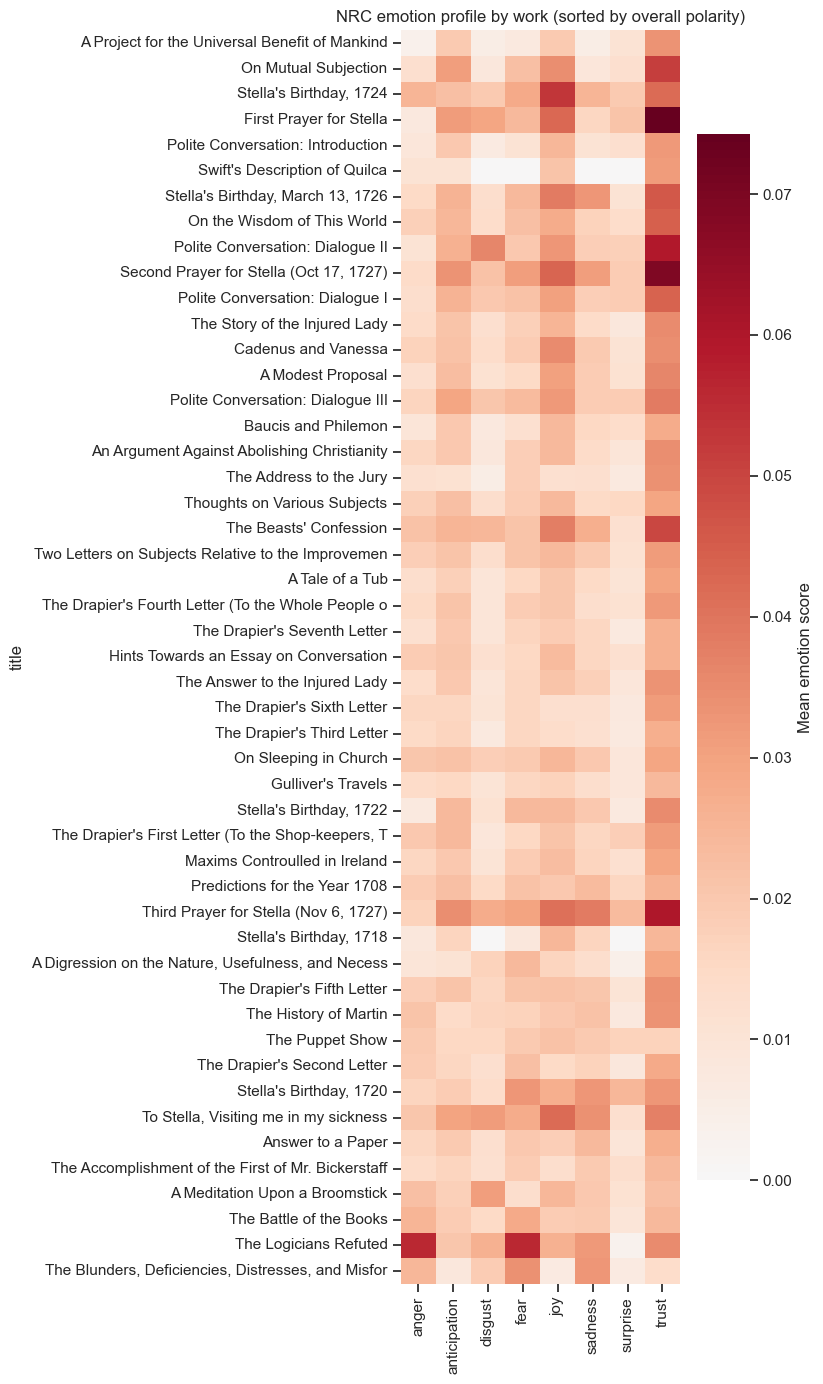

In [49]:
fig, ax = plt.subplots(figsize = (8,14))
heat_data = WORK_SENT.sort_values('polarity', ascending = False)[emo_cols[:-1]]
heat_data.index = WORK_SENT.sort_values('polarity', ascending=False).title.str[:50]

sns.heatmap(heat_data, cmap='RdBu_r', center = 0,
            cbar_kws={'label':'Mean emotion score'}, ax=ax)
ax.set_title('NRC emotion profile by work (sorted by overall polarity)', fontsize = 12)
plt.tight_layout()
plt.savefig(f"{F5_path}/sentiment_analysis/figures/sentiment_heatmap_work.png", dpi=300, bbox_inches='tight')
plt.show()

## Mean emotion by broad genre

In [50]:
GENRE_SENT=TOKEN.join(LIB[['broad_genre']], on = 'work_id').groupby('broad_genre')[emo_cols].mean()

GENRE_SENT.style.background_gradient(cmap='RdBu_r', axis=None)

,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,polarity
broad_genre,,,,,,,,,
Essay,0.018243,0.021616,0.012264,0.016863,0.023915,0.015484,0.013797,0.027901,0.010271
Political,0.016616,0.019846,0.011325,0.019067,0.020515,0.017210,0.010341,0.030818,0.006813
Religious,0.016674,0.026750,0.014980,0.022381,0.030227,0.016942,0.012929,0.044940,0.018814
Satire,0.014416,0.017737,0.011937,0.017168,0.020191,0.014777,0.010764,0.029169,0.008027
Verse,0.017491,0.022058,0.014867,0.021281,0.033330,0.022155,0.011661,0.034107,0.010786


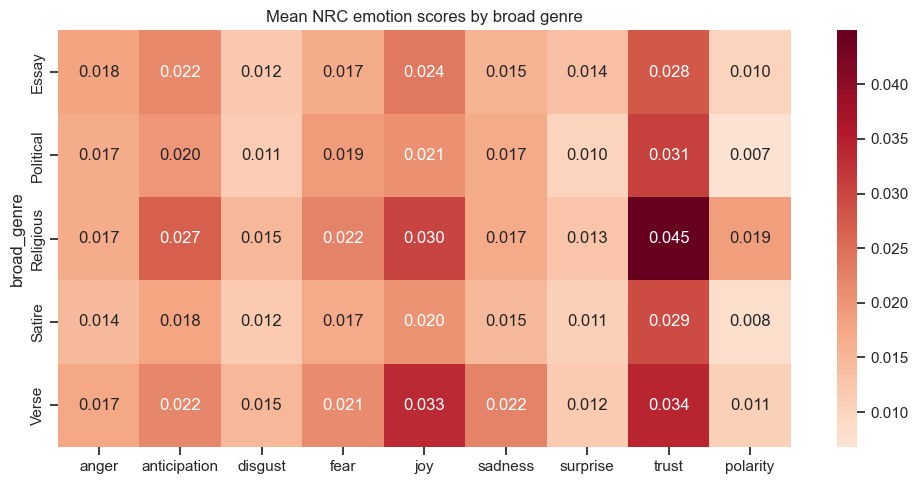

In [51]:
fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(GENRE_SENT, cmap='RdBu_r', center = 0, annot=True, fmt='.3f', ax=ax)
ax.set_title('Mean NRC emotion scores by broad genre')
plt.tight_layout()
plt.savefig(f"{F5_path}/sentiment_analysis/figures/sentiment_heatmap_genre.png", dpi=300, bbox_inches='tight')
plt.show()

## Aggregate to paragraph level

In [52]:
PARA_SENT = TOKEN.groupby(PARAS)[emo_cols].mean()

print(f'PARA_SENT: {PARA_SENT.shape}')
PARA_SENT.head()

PARA_SENT: (3579, 9)


anger  \
work_id                       part_num chap_num para_num             
accomplishment_of_predictions 1        1        1         0.071429   
                                                2         0.000000   
                                                3         0.013123   
                                                4         0.014085   
address_to_jury               1        1        1         0.012658   

                                                          anticipation  \
work_id                       part_num chap_num para_num                 
accomplishment_of_predictions 1        1        1             0.071429   
                                                2             0.000000   
                                                3             0.013123   
                                                4             0.024648   
address_to_jury               1        1        1             0.012658   

                                                           disgust      fear  \
work_id                       part_num chap_num para_num                       
accomplishment_of_predictions 1        1        1         0.071429  0.071429   
                                                2         0.000000  0.000000   
                                                3         0.014436  0.015748   
                                                4         0.003521  0.024648   
address_to_jury               1        1        1         0.012658  0.012658   

                                                               joy   sadness  \
work_id                       part_num chap_num para_num                       
accomplishment_of_predictions 1        1        1         0.000000  0.071429   
                                                2         0.000000  0.000000   
                                                3         0.014436  0.018373   
                                                4         0.010563  0.021127   
address_to_jury               1        1        1         0.000000  0.012658   

                                                          surprise     trust  \
work_id                       part_num chap_num para_num                       
accomplishment_of_predictions 1        1        1         0.071429  0.000000   
                                                2         0.000000  0.000000   
                                                3         0.013123  0.024934   
                                                4         0.010563  0.024648   
address_to_jury               1        1        1         0.012658  0.037975   

                                                          polarity  
work_id                       part_num chap_num para_num            
accomplishment_of_predictions 1        1        1        -0.071429  
                                                2         0.000000  
                                                3        -0.003937  
                                                4        -0.010563  
address_to_jury               1        1        1         0.025316

## Sentiment Trajectory

In [53]:
def plot_sentiment_trajectory(work_id, emo='polarity',window=20, figsize=(14,4)):
    sub = PARA_SENT.xs(work_id, level='work_id')
    smoothed = sub[emo].reset_index(drop=True).rolling(window).mean()

    fig, ax = plt.subplots(figsize = figsize)
    ax.plot(smoothed, linewidth=1.2)
    ax.axhline(y=0, color='gray',linestyle='--', alpha=0.5)
    ax.fill_between(range(len(smoothed)), 0, smoothed,
                    where = (smoothed>=0), color='green',alpha=0.2, label='positive')
    ax.fill_between(range(len(smoothed)), 0, smoothed,
                    where = (smoothed < 0), color='red', alpha=0.2, label='negative')
    
    title = LIB.loc[work_id,'title']
    ax.set_title(f"{title} - {emo} (rolling window = {window})")
    ax.set_xlabel('Paragraph (sequential)')
    ax.set_ylabel(emo)
    ax.legend(loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    return fig

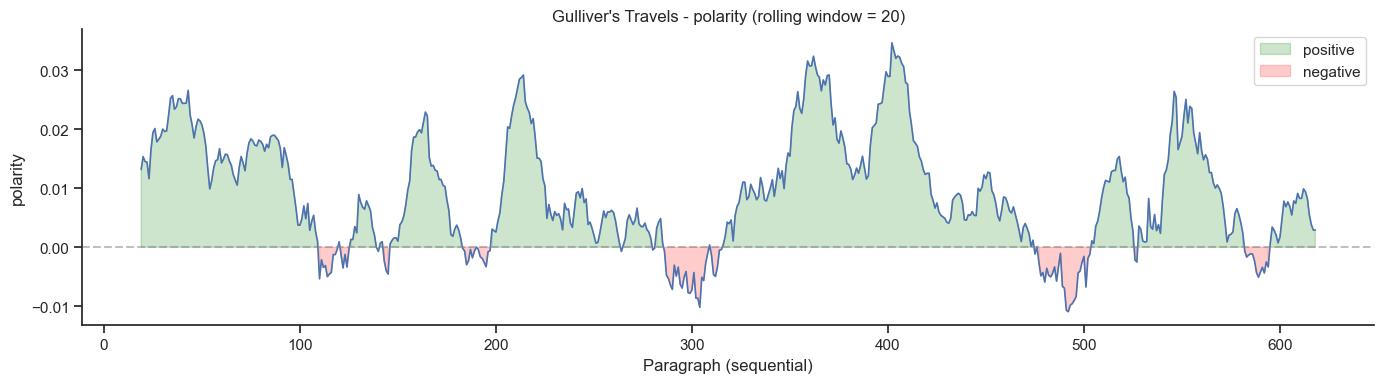

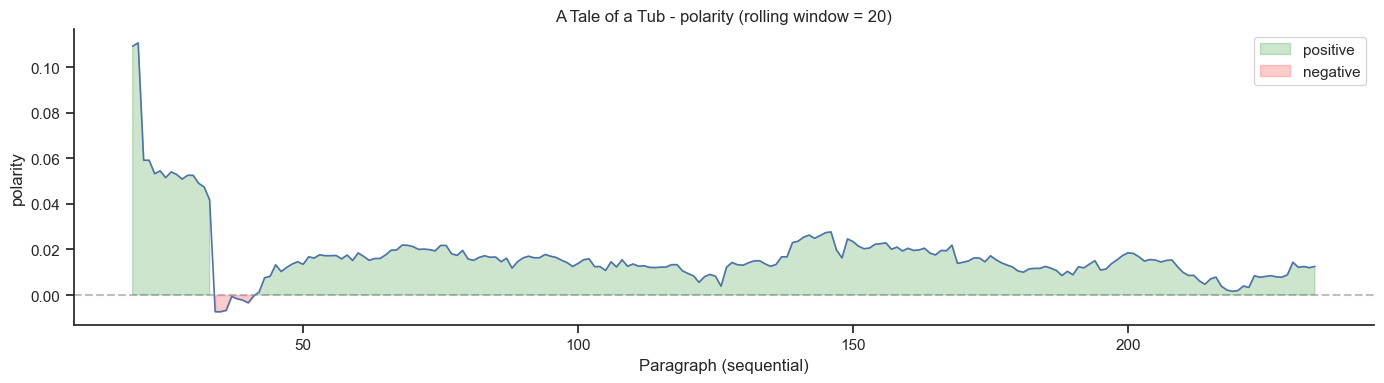

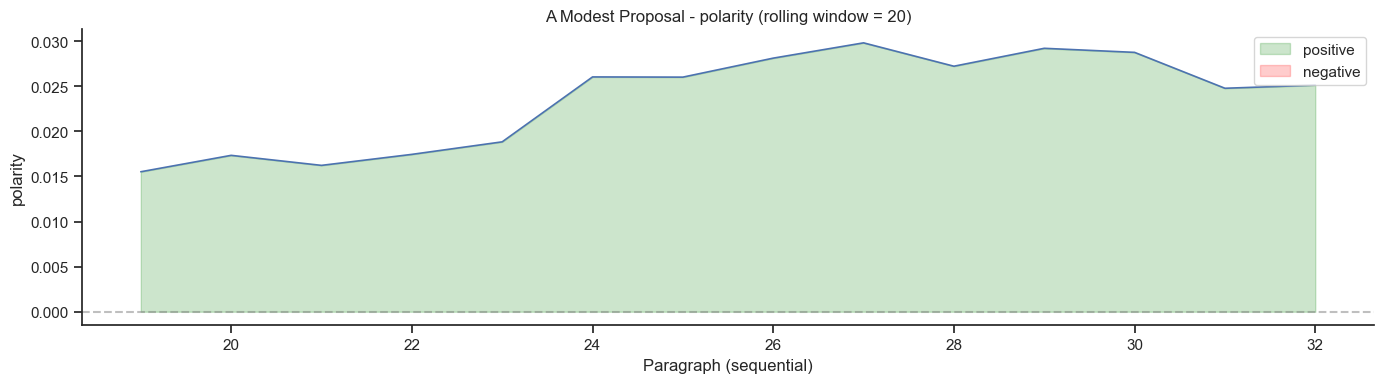

In [54]:
for work_id in ['gullivers_travels','tale_of_a_tub','modest_proposal']:
        fig=plot_sentiment_trajectory(work_id)
        fig.savefig(f"{F5_path}/sentiment_analysis/figures/sentiment_traj_{work_id}.png", dpi=300, bbox_inches='tight')
        plt.show()

## VADER sentiment (sentence-level)

In [55]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyser = SentimentIntensityAnalyzer()

In [56]:
SENT_STR = TOKEN.groupby(SENTS).term_str.apply(lambda x: x.str.cat(sep=' '))

print(f'Sentences: {len(SENT_STR):,}')
SENT_STR.head()

Sentences: 8,890


work_id                        part_num  chap_num  para_num  sent_num
accomplishment_of_predictions  1         1         1         0           an account of the death of mr partridge the al...
                                                   2         0           in a letter to a person of honour written in t...
                                                   3         0           my lord in obedience to your lordships command...
                                                             1           i had some sort of knowledge of him when i was...
                                                             2           i saw him accidentally once or twice about ten...
Name: term_str, dtype: object

In [57]:
vader_scores=SENT_STR.apply(analyser.polarity_scores).apply(pd.Series)
SENT_VADER = pd.concat([SENT_STR.rename('sent_str'), vader_scores], axis = 1)

SENT_VADER.head()

sent_str  \
work_id                       part_num chap_num para_num sent_num                                                      
accomplishment_of_predictions 1        1        1        0         an account of the death of mr partridge the al...   
                                                2        0         in a letter to a person of honour written in t...   
                                                3        0         my lord in obedience to your lordships command...   
                                                         1         i had some sort of knowledge of him when i was...   
                                                         2         i saw him accidentally once or twice about ten...   

                                                                     neg  \
work_id                       part_num chap_num para_num sent_num          
accomplishment_of_predictions 1        1        1        0         0.231   
                                                2        0         0.000   
                                                3        0         0.112   
                                                         1         0.000   
                                                         2         0.207   

                                                                     neu  \
work_id                       part_num chap_num para_num sent_num          
accomplishment_of_predictions 1        1        1        0         0.769   
                                                2        0         0.764   
                                                3        0         0.810   
                                                         1         1.000   
                                                         2         0.725   

                                                                     pos  \
work_id                       part_num chap_num para_num sent_num          
accomplishment_of_predictions 1        1        1        0         0.000   
                                                2        0         0.236   
                                                3        0         0.078   
                                                         1         0.000   
                                                         2         0.068   

                                                                   compound  
work_id                       part_num chap_num para_num sent_num            
accomplishment_of_predictions 1        1        1        0          -0.5994  
                                                2        0           0.5719  
                                                3        0          -0.4939  
                                                         1           0.0000  
                                                         2          -0.7430

## Aggregate VADER to work level

In [58]:
WORK_VADER = SENT_VADER.groupby(WORKS)[['neg','neu','pos','compound']].mean()
WORK_VADER = WORK_VADER.join(LIB[['title','broad_genre']])

print("Most positive works (VADER compound):")
print(WORK_VADER.sort_values('compound', ascending=False).head(8)[['title','broad_genre','compound']])
print("\nMost negative works (VADER compound):")
print(WORK_VADER.sort_values('compound', ascending=True).head(8)[['title','broad_genre','compound']])

Most positive works (VADER compound):
                                                                      title  \
work_id                                                                       
project_universal_benefit    A Project for the Universal Benefit of Mankind   
stella_birthday_1718                                Stella's Birthday, 1718   
prayer_for_stella_2                 Second Prayer for Stella (Oct 17, 1727)   
polite_conversation_intro                 Polite Conversation: Introduction   
description_of_quilca                         Swift's Description of Quilca   
sermon_mutual_subjection                               On Mutual Subjection   
modest_proposal                                           A Modest Proposal   
sermon_wisdom_of_this_world                     On the Wisdom of This World   

                            broad_genre  compound  
work_id                                            
project_universal_benefit        Satire  0.584842  
stella_birthday

## Compare NRC and VADER

In [59]:
sent_compare = (WORK_SENT[['polarity']].rename(columns={'polarity':'nrc_polarity'})
                .join(WORK_VADER[['compound']]
                .rename(columns={'compound':'vader_compound'}))
                .join(LIB[['title','broad_genre']]))

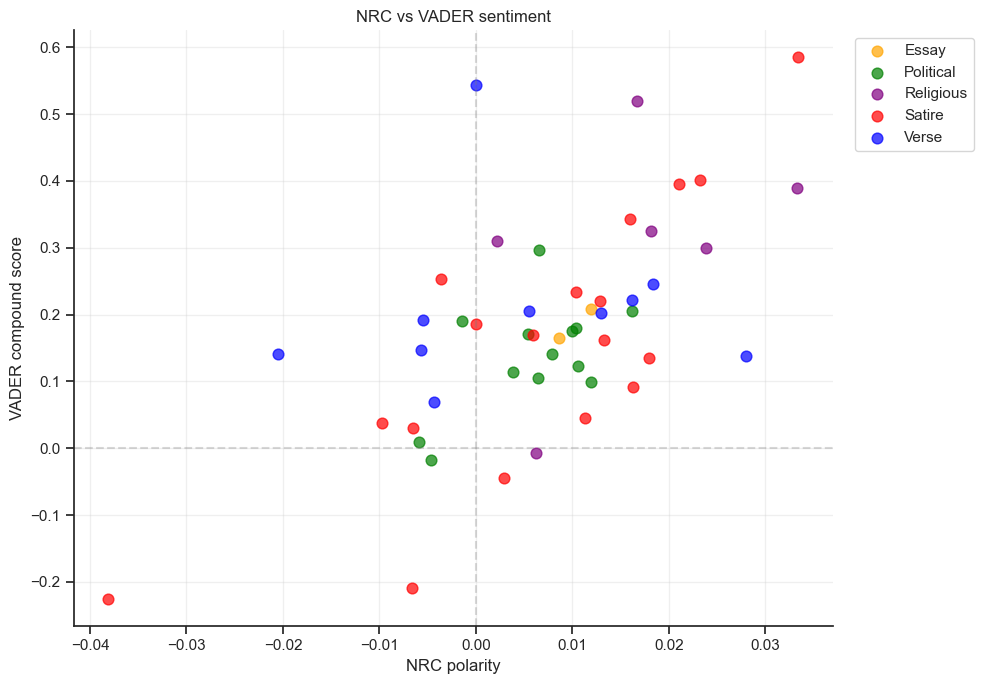

In [60]:
# NRC polarity vs VADER compound
fig, ax = plt.subplots(figsize=(10,7))
colors = {'Satire':'red','Political':'green','Verse':'blue','Religious':'purple','Essay':'orange'}
for genre, sub in sent_compare.groupby('broad_genre'):
    ax.scatter(sub.nrc_polarity, sub.vader_compound,
    label=genre, alpha = 0.7, s=60,
    color = colors.get(genre,'gray'))
ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax.axvline(0, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('NRC polarity')
ax.set_ylabel('VADER compound score')
ax.set_title("NRC vs VADER sentiment")
ax.legend(bbox_to_anchor=(1.02, 1), loc = 'upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha = 0.3)
plt.tight_layout()
plt.savefig(f"{F5_path}/sentiment_analysis/figures/sentiment_nrc_vs_vader.png", dpi = 300, bbox_inches='tight')
plt.show()

In [61]:
VOCAB.to_csv(f"{F5_path}/sentiment_analysis/VOCAB_sentiment.csv")
WORK_SENT.to_csv(f"{F5_path}/sentiment_analysis/SENT_work_nrc.csv")
PARA_SENT.to_csv(f"{F5_path}/sentiment_analysis/SENT_para_nrc.csv")
WORK_VADER.to_csv(f"{F5_path}/sentiment_analysis/SENT_work_vader.csv")
SENT_VADER.to_csv(f"{F5_path}/sentiment_analysis/SENT_sentence_vader.csv")